In [1]:
import pandas as pd

df = pd.read_parquet("v2/dictionary.parquet")

# All definitions of a word, Webster's first, then Open English WordNet
print(df[df["word"].str.lower() == "computer"][["pos", "definition", "source"]])

# Only the public-domain Webster's rows
webster = df[df["source"] == "webster1913"]

        pos                                         definition       source
71478  noun                                  One who computes.  webster1913
71479  noun  a machine for performing calculations automati...         oewn
71480  noun  an expert at calculation (or at operating calc...         oewn


In [16]:
import random

def build_wordset(df: pd.DataFrame, n: int) -> set[str]:
    words = df["word"].str.lower()
    mask = (words.str.len() == n) & words.str.isalpha()  # drop multiword/hyphenated/apostrophe entries
    return set(words[mask])

def countTillWord(df: pd.DataFrame, numCharacters: int) -> int:
    words_n = build_wordset(df, numCharacters)
    counter = 0
    while(True):
        myWord = ""
        for i in range(0, numCharacters):
            myWord += chr(random.randint(97,122))
        if myWord in words_n or counter == 100000:
            break
        else:
            counter+=1
    return counter

In [21]:
runsTill = int(input("What's the max string length you want to check till: "))
sampleSize = int(input("How many samples per string length: "))
results = pd.DataFrame(columns = ["#", "Characters", "Sample #", "runsTill"])
for i in range(1, runsTill+1):
    for j in range(1, sampleSize+1):
        new_row = {"#": (i-1)*j+j, "Characters": i, "Sample #": j, "runsTill": countTillWord(df, i)}
        temp_df = pd.DataFrame([new_row])
        results = pd.concat([results, temp_df], ignore_index = True)

results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           300 non-null    object
 1   Characters  300 non-null    object
 2   Sample #    300 non-null    object
 3   runsTill    300 non-null    object
dtypes: object(4)
memory usage: 9.5+ KB


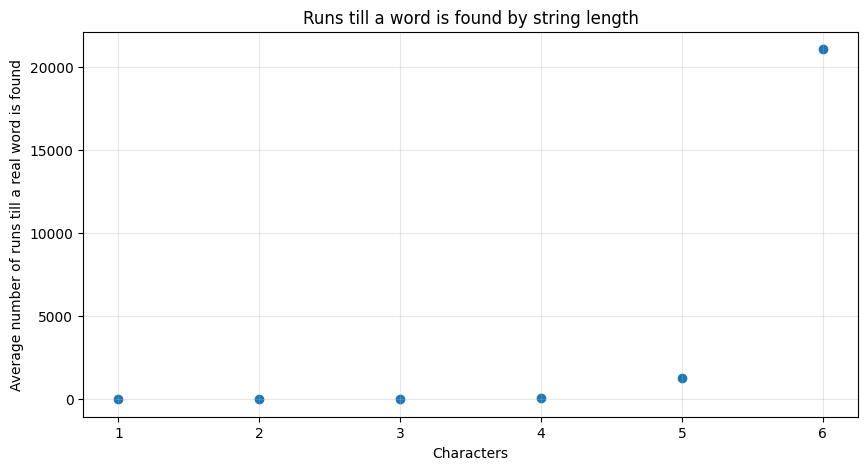

In [23]:
import matplotlib.pyplot as plt

avg = results.groupby("Characters", as_index=False)["runsTill"].mean()

plt.figure(figsize=(10, 5))
plt.scatter(avg["Characters"], avg["runsTill"])
plt.xlabel("Characters")
plt.ylabel("Average number of runs till a real word is found")
plt.title("Runs till a word is found by string length")
plt.grid(alpha=0.3)
plt.show()

Characters  Probability (%)
         2            69.44
         3            11.39
         4             1.10
         5             0.08
         6             0.00


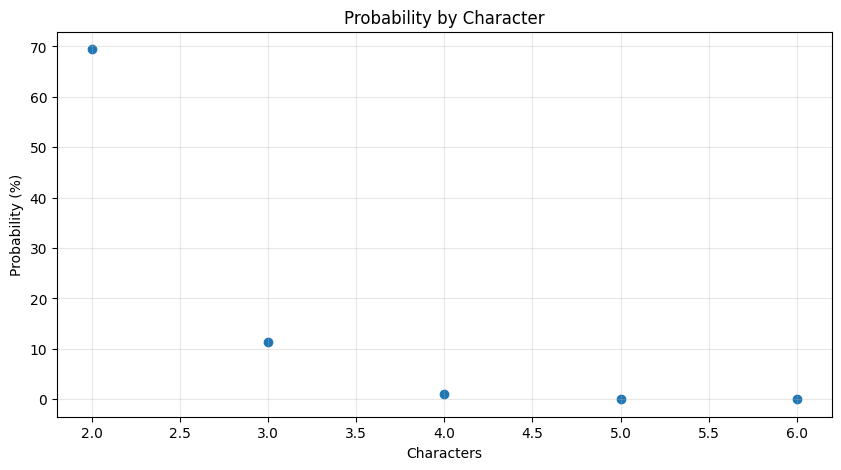

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure runsTill is numeric
results["runsTill"] = pd.to_numeric(results["runsTill"], errors="coerce")

# Average runsTill per character
avg = results.groupby("Characters", as_index=False)["runsTill"].mean()

# Remove characters whose average is 0 (or NaN) to avoid division by zero
avg = avg[avg["runsTill"] > 0].copy()

# Convert to probability (%)
avg["Probability (%)"] = 100 / avg["runsTill"]

# Sort for a clean table and axis (remove if Characters is non-numeric text you want unsorted)
avg = avg.sort_values("Characters")

# Table
table = avg[["Characters", "Probability (%)"]].copy()
table["Probability (%)"] = table["Probability (%)"].round(2)
print(table.to_string(index=False))

# Scatter plot: characters vs probability
plt.figure(figsize=(10, 5))
plt.scatter(avg["Characters"], avg["Probability (%)"])
plt.xlabel("Characters")
plt.ylabel("Probability (%)")
plt.title("Probability by Character")
plt.grid(alpha=0.3)
plt.show()

Average runsTill by Character (growth): y = 0.007932 * exp(2.418 * x), R² = 0.9213
Probability by Character (decay): y = 1.261e+04 * exp(-2.418 * x), R² = 0.7383


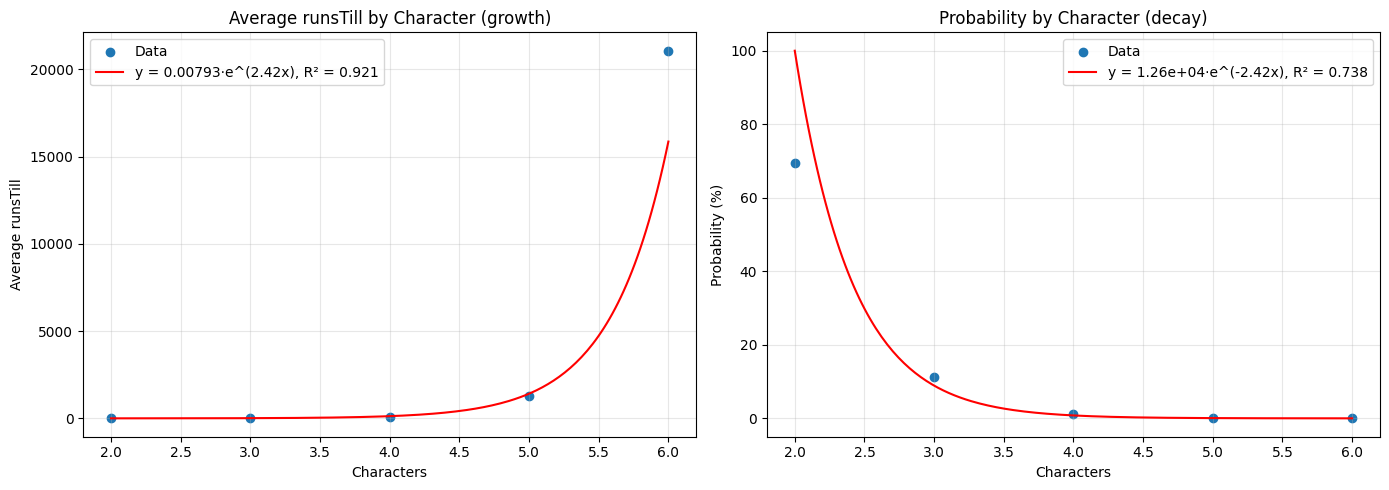

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Data prep ---
results["runsTill"] = pd.to_numeric(results["runsTill"], errors="coerce")
results["Characters"] = pd.to_numeric(results["Characters"], errors="coerce")

avg = results.groupby("Characters", as_index=False)["runsTill"].mean()
avg = avg[avg["runsTill"] > 0].copy()
avg["Probability (%)"] = 100 / avg["runsTill"]
avg = avg.sort_values("Characters")

x = avg["Characters"].to_numpy(dtype=float)
x_line = np.linspace(x.min(), x.max(), 200)

def fit_exp(ax, x, y, ylabel, title):
    b, log_a = np.polyfit(x, np.log(y), 1)
    a = np.exp(log_a)
    pred = a * np.exp(b * x)

    # R^2 on the original scale
    ss_res = np.sum((y - pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot

    ax.scatter(x, y, label="Data")
    ax.plot(x_line, a * np.exp(b * x_line), color="red",
            label=f"y = {a:.3g}·e^({b:.3g}x), R² = {r2:.3f}")
    ax.set_xlabel("Characters")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()

    print(f"{title}: y = {a:.4g} * exp({b:.4g} * x), R² = {r2:.4f}")
    return a, b

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

a1, b1 = fit_exp(axes[0], x, avg["runsTill"].to_numpy(),
                 "Average runsTill", "Average runsTill by Character (growth)")

a2, b2 = fit_exp(axes[1], x, avg["Probability (%)"].to_numpy(),
                 "Probability (%)", "Probability by Character (decay)")

plt.tight_layout()
plt.show()